In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import vector
import matplotlib

In [2]:
file = uproot.open("sample_root_files/output_570.root")

In [3]:
events_tree = file['Events']

In [4]:
jet_pt = events_tree['Jet_pt'].array()
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [5]:
jet_pt_above_500 = jet_pt>500
eft_coeff_above_500 = []
eft_coeff_below_500 = []

for i in range(len(jet_pt_above_500)):
    if True in jet_pt_above_500[i]:
        eft_coeff_above_500.append(eft_coeff[i])
    else:
        eft_coeff_below_500.append(eft_coeff[i])

In [6]:
# let's make a 3D graph with the x-axis as the event number, the y-axis as the number of the coefficient, and
# the color as the value of the coefficient

x_axis_above_500 = range(1,len(eft_coeff_above_500)+1)                  # Setting event numbers
x_axis_below_500 = range(1,len(eft_coeff_below_500)+1)

y_axis = range(1, len(eft_coeff[0])+1)                                  # Setting coefficient numbers

b = False
a = 0

number_of_coeff_for_above_500 = []
number_of_coeff_for_below_500 = []

while b == False:                                       # This while loop repeats the y_axis so we can assign 561 coefficients to 
    for i in y_axis:                                    # a single event (equivalent of assigning 561 y-values to a single x-value).
        number_of_coeff_for_above_500.append(i)
    a += 1
    if a == len(x_axis_above_500):
        b = True

d = False
c = 0
while d == False:                                        
    for i in y_axis:                                   
        number_of_coeff_for_below_500.append(i)
    c += 1
    if c == len(x_axis_below_500):
        d = True

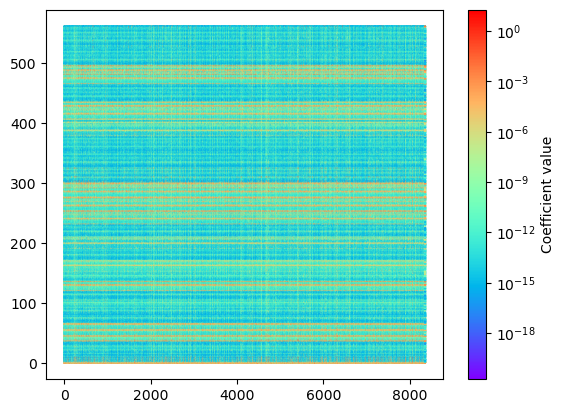

In [7]:
# Graphing the scatter plot

plt.scatter(np.repeat(x_axis_above_500, len(y_axis)), np.array(number_of_coeff_for_above_500), 
            c = np.array(ak.flatten(eft_coeff_above_500)), cmap='rainbow', s = 0.5, norm=matplotlib.colors.LogNorm())

# plt.yscale('log')
# plt.xscale('log')
plt.colorbar(label='Coefficient value')
plt.show()

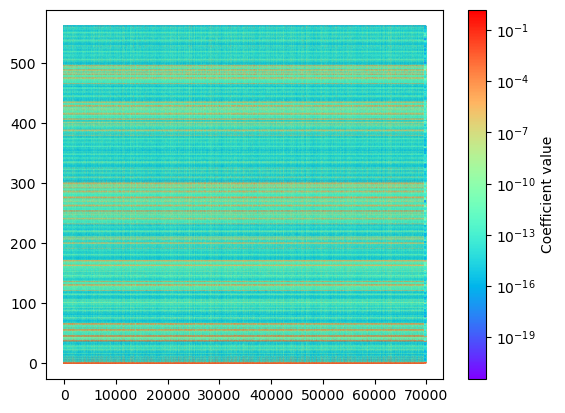

In [8]:
plt.scatter(np.repeat(x_axis_below_500, len(y_axis)), np.array(number_of_coeff_for_below_500), 
            c = np.array(ak.flatten(eft_coeff_below_500)), cmap='rainbow', s = 0.5, norm=matplotlib.colors.LogNorm())

# plt.yscale('log')
# plt.xscale('log')
plt.colorbar(label='Coefficient value')
plt.show()